<a href="https://colab.research.google.com/github/Malope-cmd/Porfolio-Optimization/blob/main/Portfolio_Optimization_Notebook_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import yfinance as yf

In [ ]:
def plot_stock_monte_carlo(ticker_symbol, forecast_months=1.5, num_simulations=500, seed=None):
    # 1. Setup Parameters
    if seed is not None:
        np.random.seed(seed)

    trading_days_per_year = 252
    forecast_days = int(trading_days_per_year / 12 * forecast_months)
    data_start = "2024-01-01"
    data_end = "2026-05-31"
    plot_start = "2026-01-01"

    # 2. Download Data
    data = yf.download(ticker_symbol, start=data_start, end=data_end, auto_adjust=True)
    if data.empty:
        print(f"No data found for {ticker_symbol}")
        return pd.DataFrame()

    close_prices = data["Close"]
    returns = close_prices.pct_change().dropna()
    mu, sigma = returns.mean(), returns.std()

    last_val = close_prices.iloc[-1]
    last_price = float(last_val.iloc[0]) if hasattr(last_val, "iloc") else float(last_val)

    # 3. Run Simulation
    sim_results = np.zeros((forecast_days, num_simulations))
    for i in range(num_simulations):
        path = np.zeros(forecast_days)
        path[0] = last_price
        shocks = np.random.normal(mu, sigma, forecast_days - 1)
        for j in range(1, forecast_days):
            path[j] = path[j-1] * (1 + shocks[j-1])
        sim_results[:, i] = path

    # 4. Calculate Stats
    mean_p = np.mean(sim_results, axis=1)
    med_p = np.percentile(sim_results, 50, axis=1) # Set here the percentile path you want to single out
    p25 = np.percentile(sim_results, 25, axis=1)
    p75 = np.percentile(sim_results, 75, axis=1)

    # 5. Dates for Plotting
    hist_prices = close_prices[close_prices.index >= plot_start]
    hist_series = hist_prices.iloc[:, 0] if isinstance(hist_prices, pd.DataFrame) else hist_prices

    forecast_dates = pd.date_range(start=close_prices.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
    forecast_series = pd.Series(med_p, index=forecast_dates)

    # 6. Plotting
    plt.figure(figsize=(16, 8))
    plt.plot(hist_series.index, hist_series.values, label="Historical Price", color="blue", lw=2)
    plt.plot(forecast_dates, mean_p, color="green", ls="--", lw=2.5, label="Mean Path")
    plt.plot(forecast_dates, med_p, color="red", lw=2.5, label="50th Percentile (Median)")
    plt.fill_between(forecast_dates, p25, p75, color="red", alpha=0.15, label="25th-75th Percentile Range")

    plt.title(f"Monte Carlo Statistical Forecast: {ticker_symbol} (Seed: {seed})")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 7. Return DataFrame
    combined_df = pd.concat([hist_series, forecast_series]).to_frame(name="Price")
    combined_df.index.name = "Date"
    return combined_df

[*********************100%***********************]  1 of 1 completed


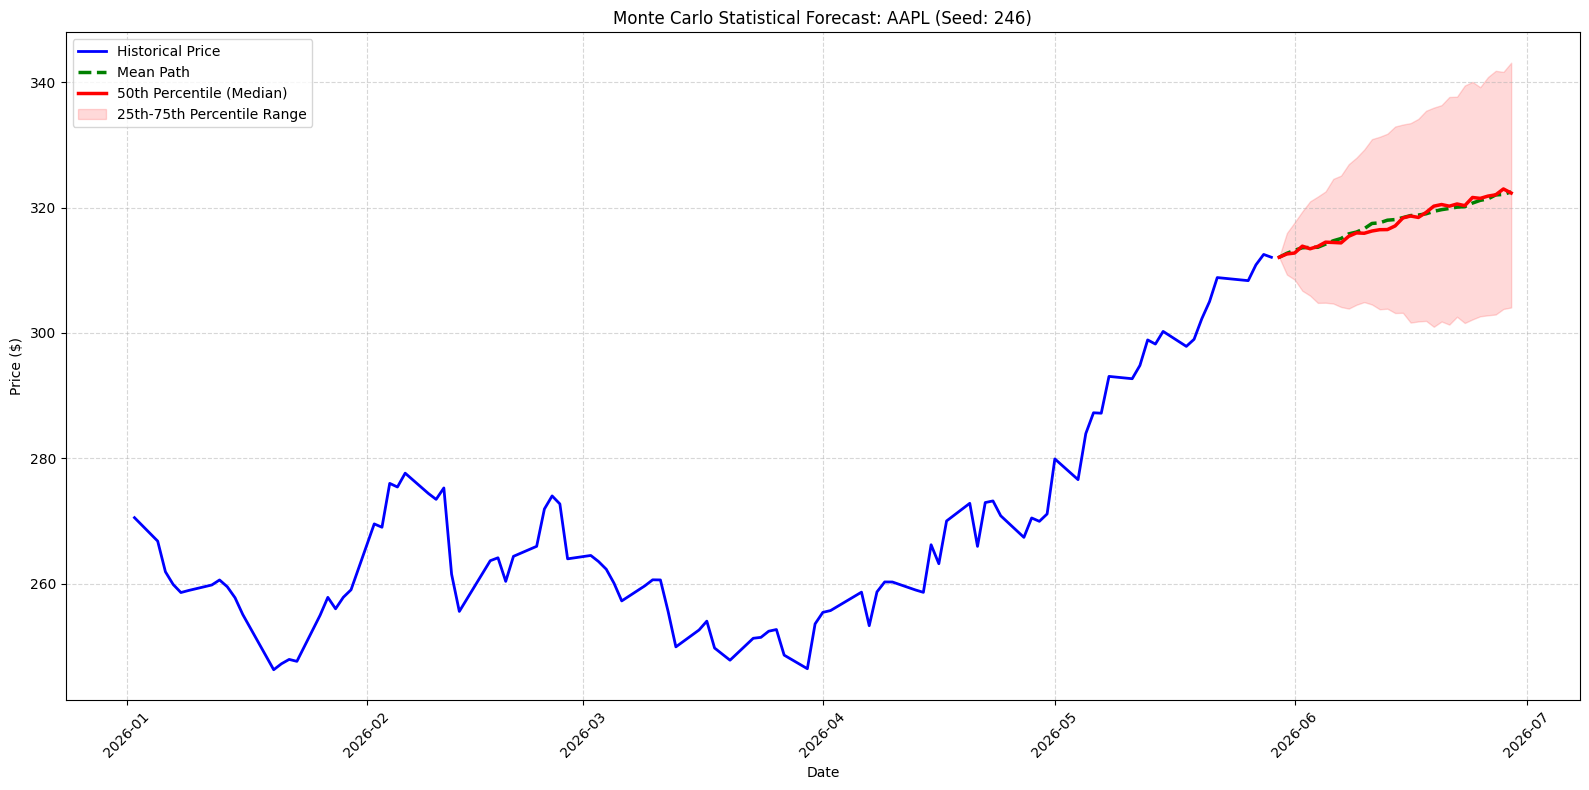

In [ ]:
apple_df = plot_stock_monte_carlo('AAPL', seed=246)

[*********************100%***********************]  1 of 1 completed


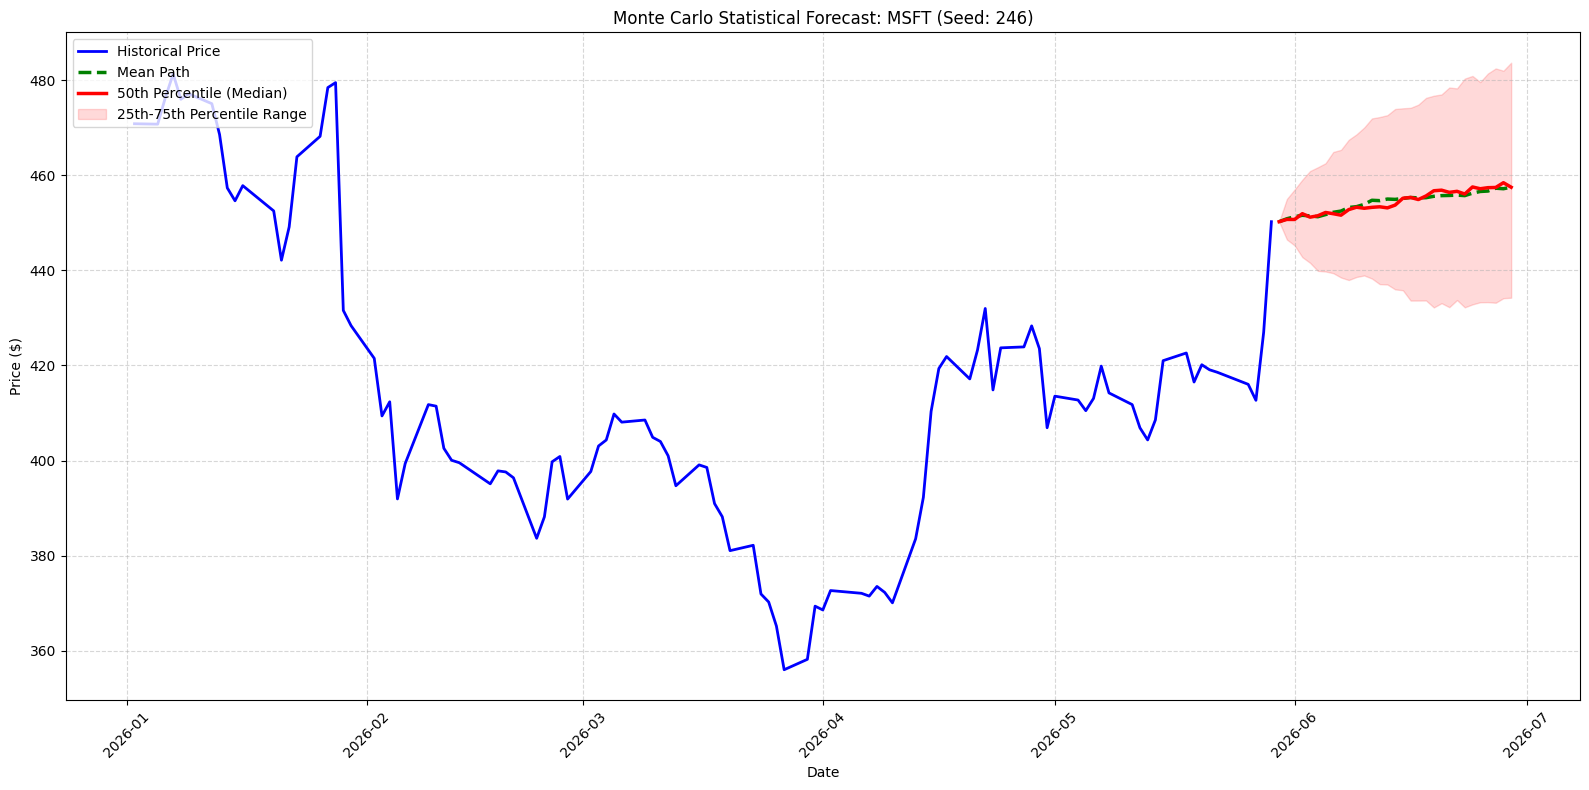

In [ ]:
microsoft_df = plot_stock_monte_carlo('MSFT', seed=246)

[*********************100%***********************]  1 of 1 completed


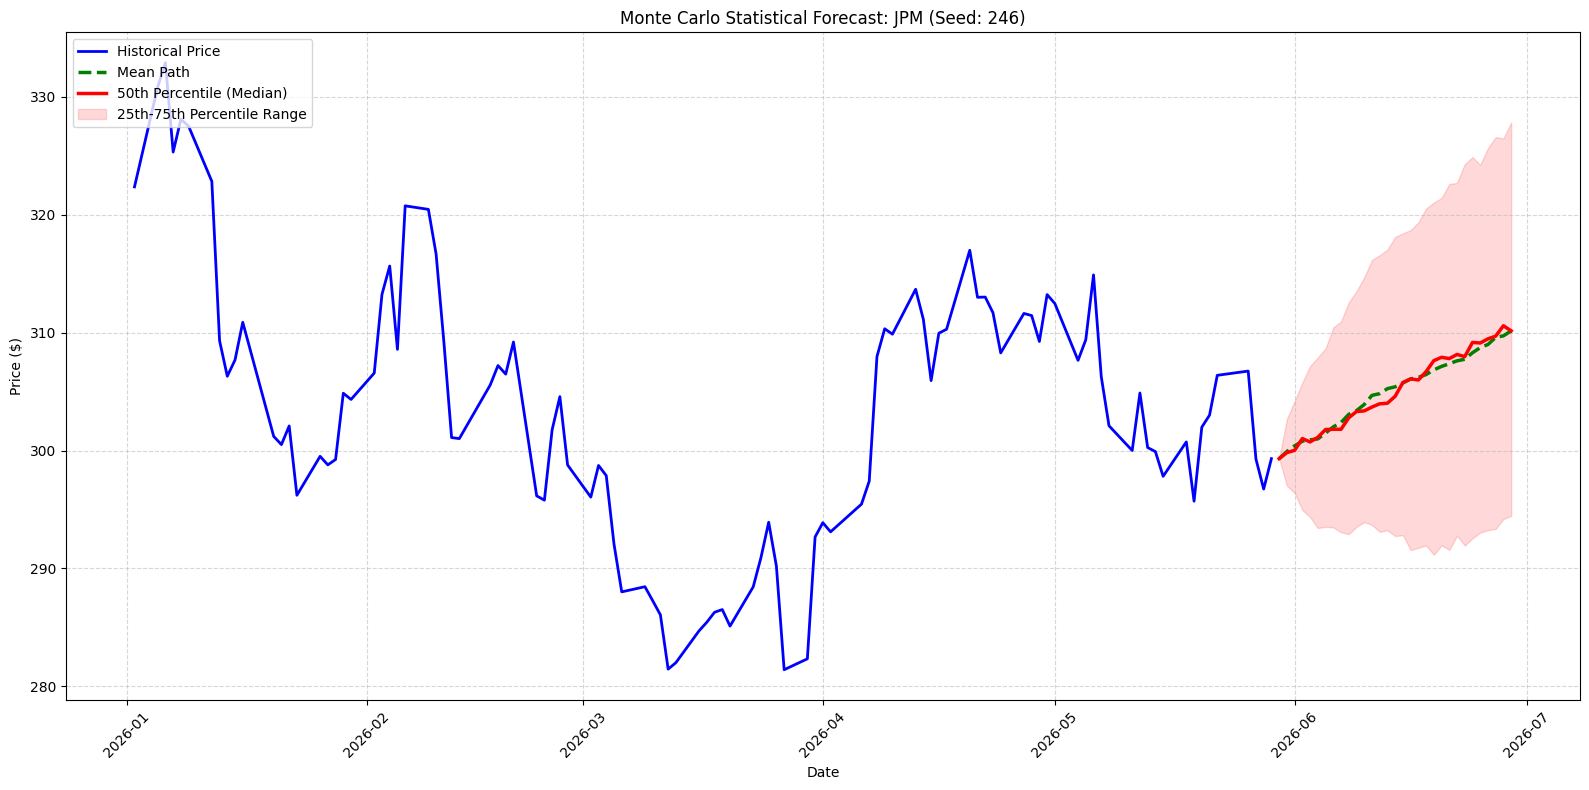

In [ ]:
jpmorgan_df = plot_stock_monte_carlo('JPM', seed=246)

[*********************100%***********************]  1 of 1 completed


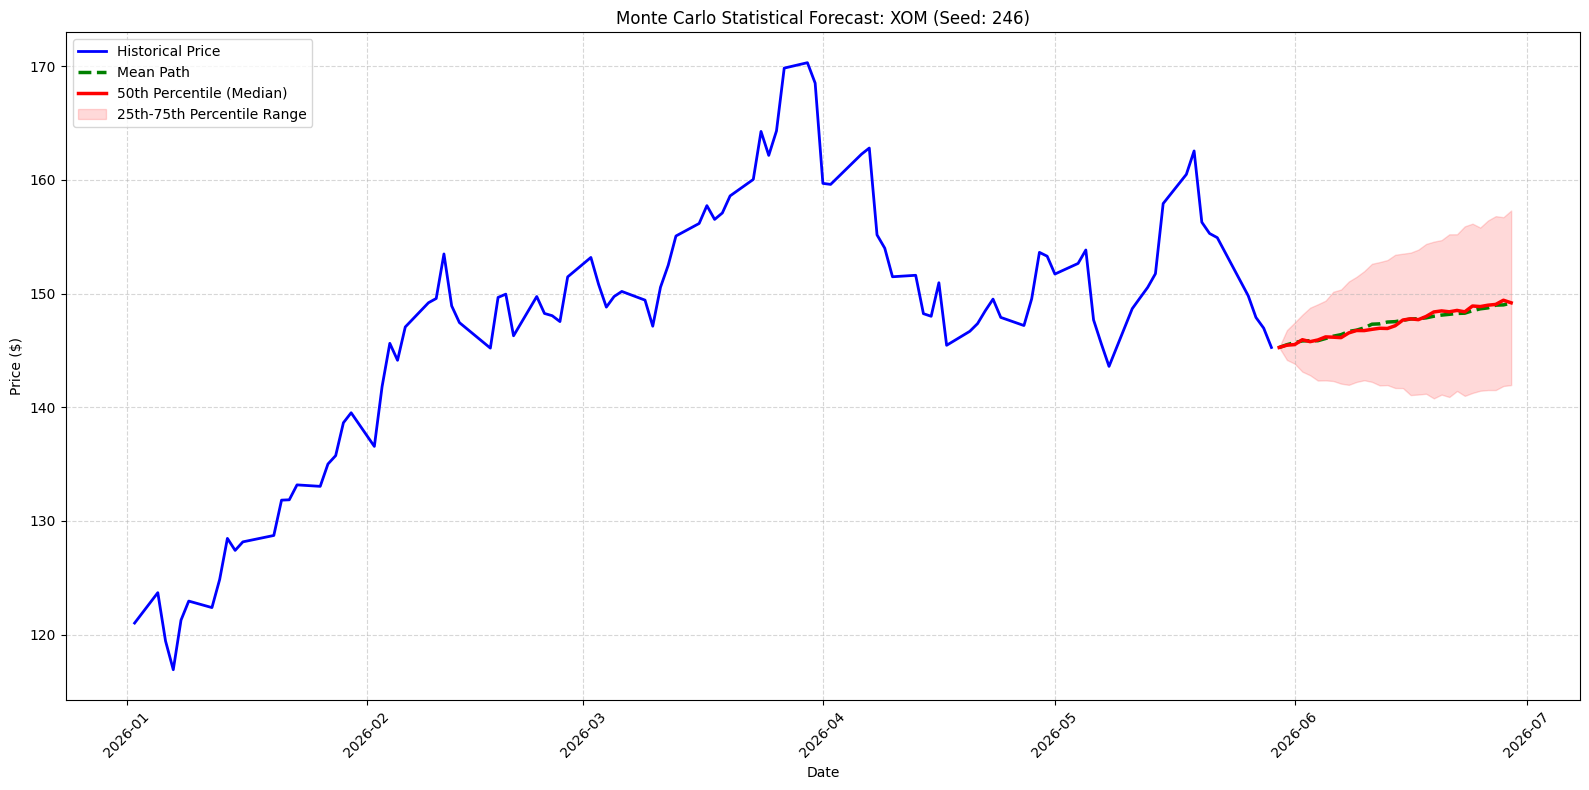

In [ ]:
exxon_df = plot_stock_monte_carlo('XOM', seed=246)

In [ ]:
combined_all_stocks_df = pd.concat([
    apple_df.rename(columns={'Price': 'AAPL'}),
    microsoft_df.rename(columns={'Price': 'MSFT'}),
    jpmorgan_df.rename(columns={'Price': 'JPM'}),
    exxon_df.rename(columns={'Price': 'XOM'})
], axis=1)

In [ ]:
from google.colab import files

excel_filename_i = 'combined_forecasts_data.xlsx'
combined_all_stocks_df.to_excel(excel_filename_i, index=True)

files.download(excel_filename_i)
print(f'Successfully exported {excel_filename_i}.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully exported combined_forecasts_data.xlsx.


In [ ]:
display(combined_all_stocks_df.head())
display(combined_all_stocks_df.tail())

,AAPL,MSFT,JPM,XOM
Date,,,,
2026-01-02,270.507416,470.843201,322.368652,121.016518
2026-01-05,266.764374,470.753632,330.846832,123.690422
2026-01-06,261.873444,476.388519,332.906250,119.437820
2026-01-07,259.847198,481.326508,325.325073,116.911911
2026-01-08,258.559631,475.990265,328.110840,121.273056


,AAPL,MSFT,JPM,XOM
Date,,,,
2026-06-25,321.456446,457.171262,309.122824,148.858069
2026-06-26,321.821151,457.395857,309.476097,148.980214
2026-06-27,322.024806,457.437717,309.706947,149.048425
2026-06-28,322.960013,458.438924,310.585574,149.415594
2026-06-29,322.311365,457.490716,310.150842,149.189058


In [ ]:
combined_all_stocks_df.head()

,AAPL,MSFT,JPM,XOM
Date,,,,
2026-01-02,270.507416,470.843201,322.368652,121.016518
2026-01-05,266.764374,470.753632,330.846832,123.690422
2026-01-06,261.873444,476.388519,332.906250,119.437820
2026-01-07,259.847198,481.326508,325.325073,116.911911
2026-01-08,258.559631,475.990265,328.110840,121.273056


In [ ]:
from google.colab import files

csv_filename = 'stock_forecast_combined_reproducible.csv'
combined_all_stocks_df.to_csv(csv_filename)

files.download(csv_filename)
print(f'Successfully exported {csv_filename}. Results are now reproducible using seed 246.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully exported stock_forecast_combined_reproducible.csv. Results are now reproducible using seed 246.


In [ ]:
forecast_data = combined_all_stocks_df.copy()

In [ ]:
forecast_data.describe()

,AAPL,MSFT,JPM,XOM
count,133.000000,133.000000,133.000000,133.000000
mean,279.707239,423.176591,303.786469,147.451431
std,25.699911,31.831584,10.064273,10.079029
min,246.242508,355.998932,281.399872,116.911911
25%,258.889008,399.734222,298.780914,145.919101
50%,270.460815,419.089996,304.332520,148.396373
75%,310.850006,453.258937,309.316986,151.720200
max,322.960013,481.326508,332.906250,170.313995


In [ ]:
forecast_data.tail()

,AAPL,MSFT,JPM,XOM
Date,,,,
2026-06-25,321.456446,457.171262,309.122824,148.858069
2026-06-26,321.821151,457.395857,309.476097,148.980214
2026-06-27,322.024806,457.437717,309.706947,149.048425
2026-06-28,322.960013,458.438924,310.585574,149.415594
2026-06-29,322.311365,457.490716,310.150842,149.189058


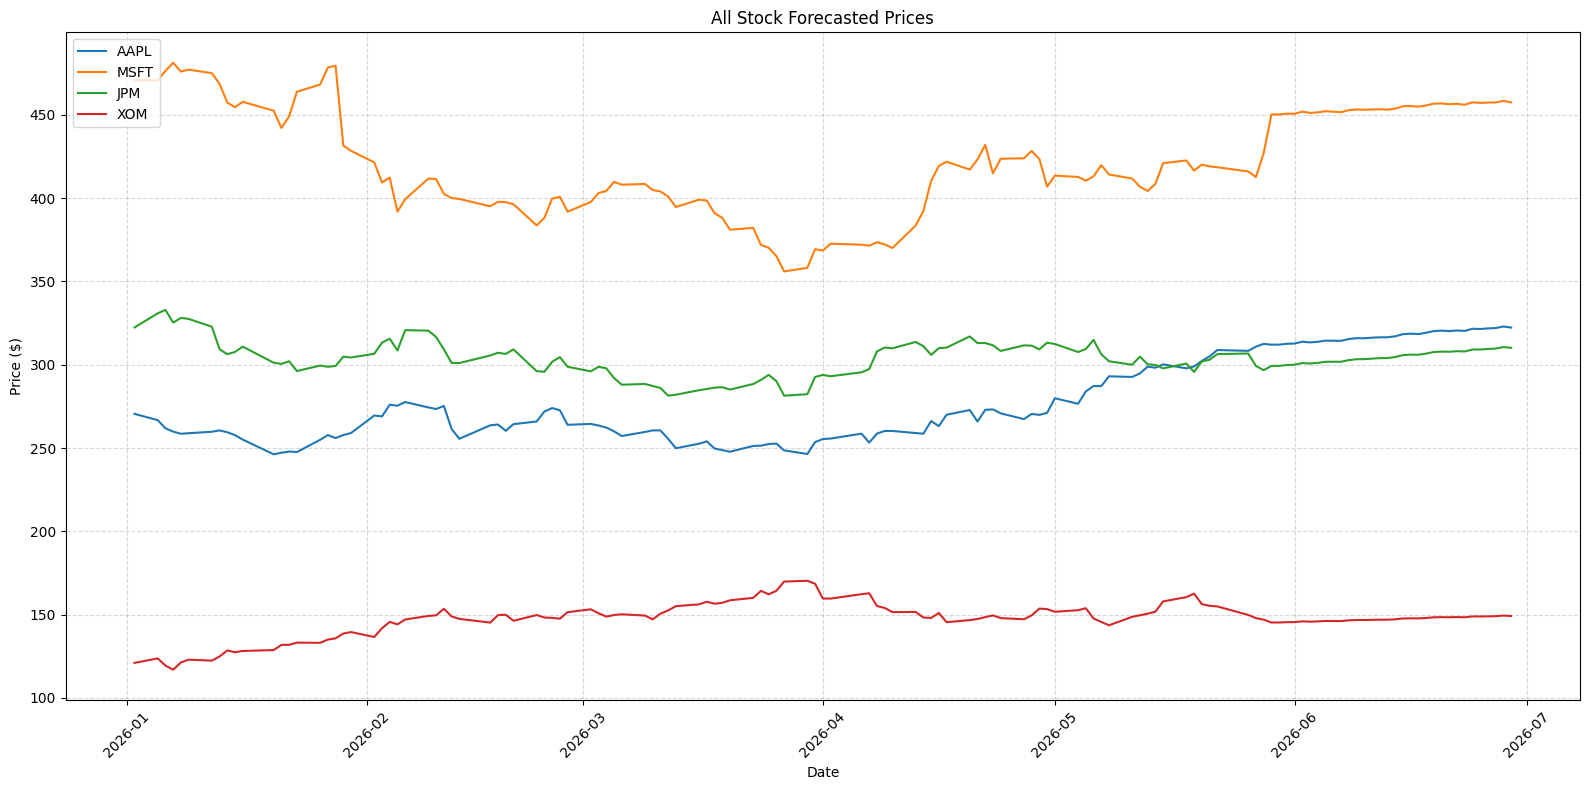

In [ ]:
plt.figure(figsize=(16, 8))

# Plot each stock with a different color
for column in combined_all_stocks_df.columns:
    plt.plot(combined_all_stocks_df.index, combined_all_stocks_df[column], label=column)

plt.title("All Stock Forecasted Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
combined_all_stocks_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 133 entries, 2026-01-02 to 2026-06-29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    133 non-null    float64
 1   MSFT    133 non-null    float64
 2   JPM     133 non-null    float64
 3   XOM     133 non-null    float64
dtypes: float64(4)
memory usage: 5.2 KB


In [ ]:
cols = ['JPM', 'AAPL']

jpm_aapl = combined_all_stocks_df[cols]

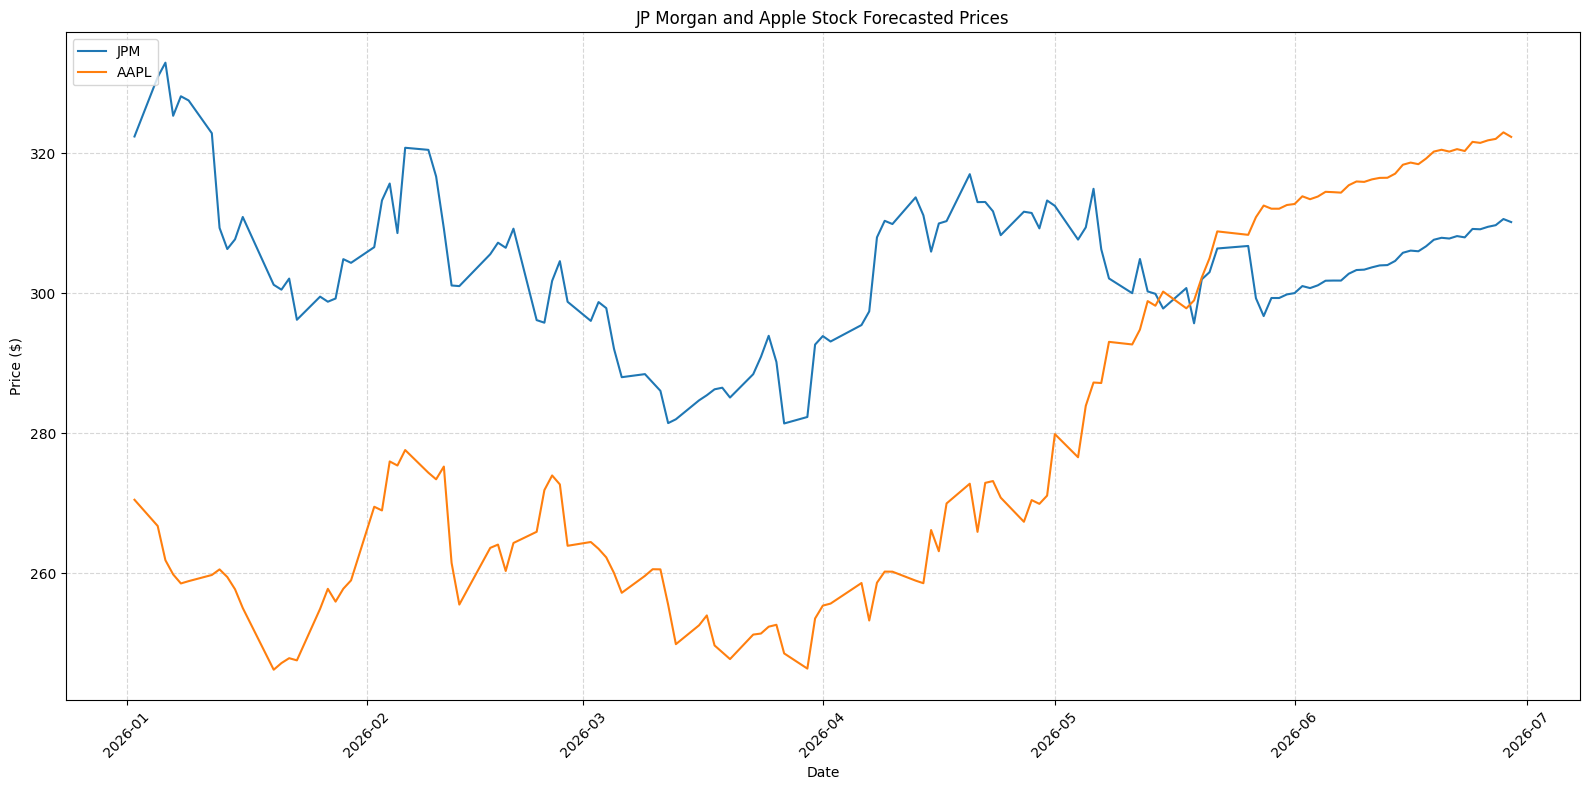

In [ ]:
plt.figure(figsize=(16, 8))

# Plot each stock with a different color
for column in jpm_aapl.columns:
    plt.plot(jpm_aapl.index, combined_all_stocks_df[column], label=column)

plt.title("JP Morgan and Apple Stock Forecasted Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Assuming the forecast starts from 2026-01-02 based on previous output and the plot_stock_monte_carlo function.
# We can verify this from the `combined_all_stocks_df` index.

# Filter for forecasted data only (assuming forecast starts from the first date in combined_all_stocks_df)
forecast_only_df = combined_all_stocks_df.copy()

# Filter for June data
june_forecast_df = forecast_only_df[forecast_only_df.index.month == 6]

display(june_forecast_df.head())
display(june_forecast_df.tail())

,AAPL,MSFT,JPM,XOM
Date,,,,
2026-06-01,312.733322,450.708802,300.013269,145.513965
2026-06-02,313.832000,451.923045,301.015550,145.942696
2026-06-03,313.414404,451.191097,300.726923,145.772966
2026-06-04,313.795272,451.485222,301.119493,145.919101
2026-06-05,314.470729,452.178917,301.778551,146.191053


,AAPL,MSFT,JPM,XOM
Date,,,,
2026-06-25,321.456446,457.171262,309.122824,148.858069
2026-06-26,321.821151,457.395857,309.476097,148.980214
2026-06-27,322.024806,457.437717,309.706947,149.048425
2026-06-28,322.960013,458.438924,310.585574,149.415594
2026-06-29,322.311365,457.490716,310.150842,149.189058


In [ ]:
june_forecast_df.describe()

,AAPL,MSFT,JPM,XOM
count,29.000000,29.000000,29.000000,29.000000
mean,317.899032,454.583413,305.384426,147.493756
std,3.133783,2.351062,3.256362,1.197417
min,312.733322,450.708802,300.013269,145.513965
25%,315.410223,452.784737,302.775773,146.543642
50%,318.335789,454.898091,305.768018,147.675433
75%,320.475817,456.747749,307.968150,148.477264
max,322.960013,458.438924,310.585574,149.415594


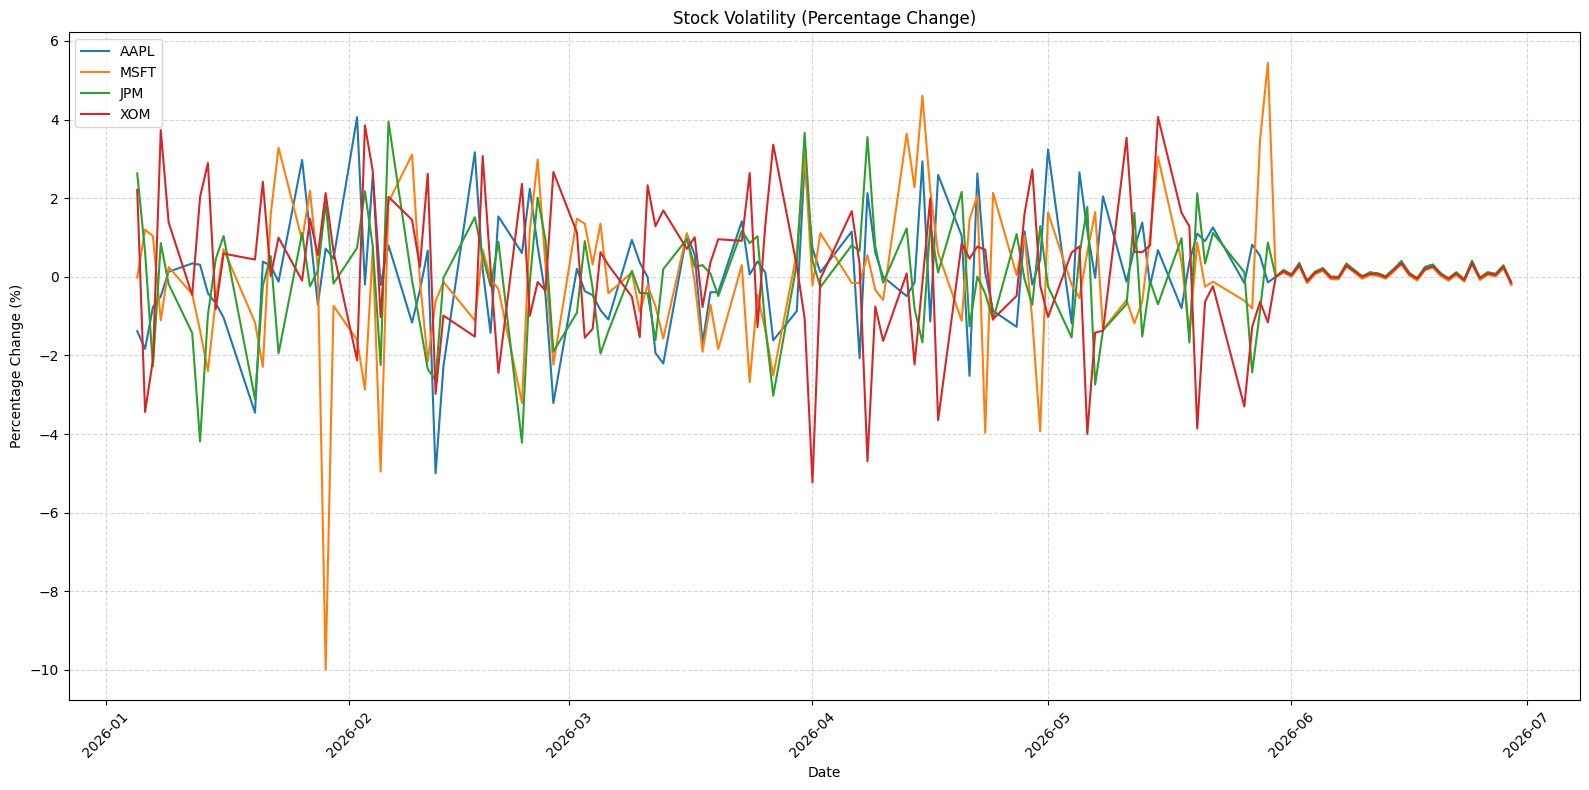

In [ ]:
plt.figure(figsize=(16, 8))

# Calculate percentage change for each stock
percentage_change_df = forecast_only_df.pct_change().dropna()

# Plot the percentage change for each stock
for column in percentage_change_df.columns:
    plt.plot(percentage_change_df.index, percentage_change_df[column] * 100, label=column)

plt.title("Stock Volatility (Percentage Change)")
plt.xlabel("Date")
plt.ylabel("Percentage Change (%)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

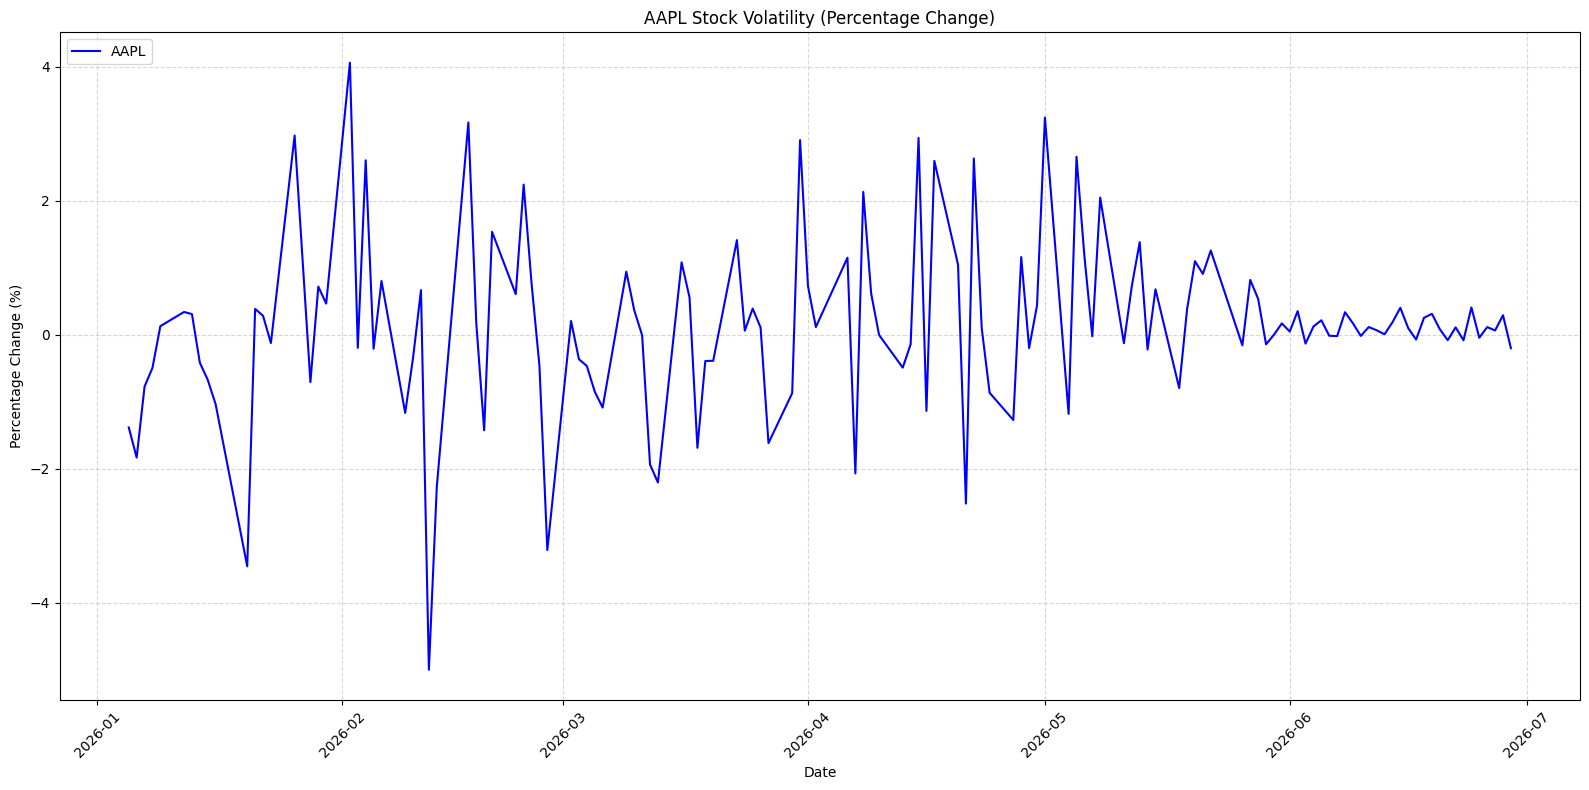

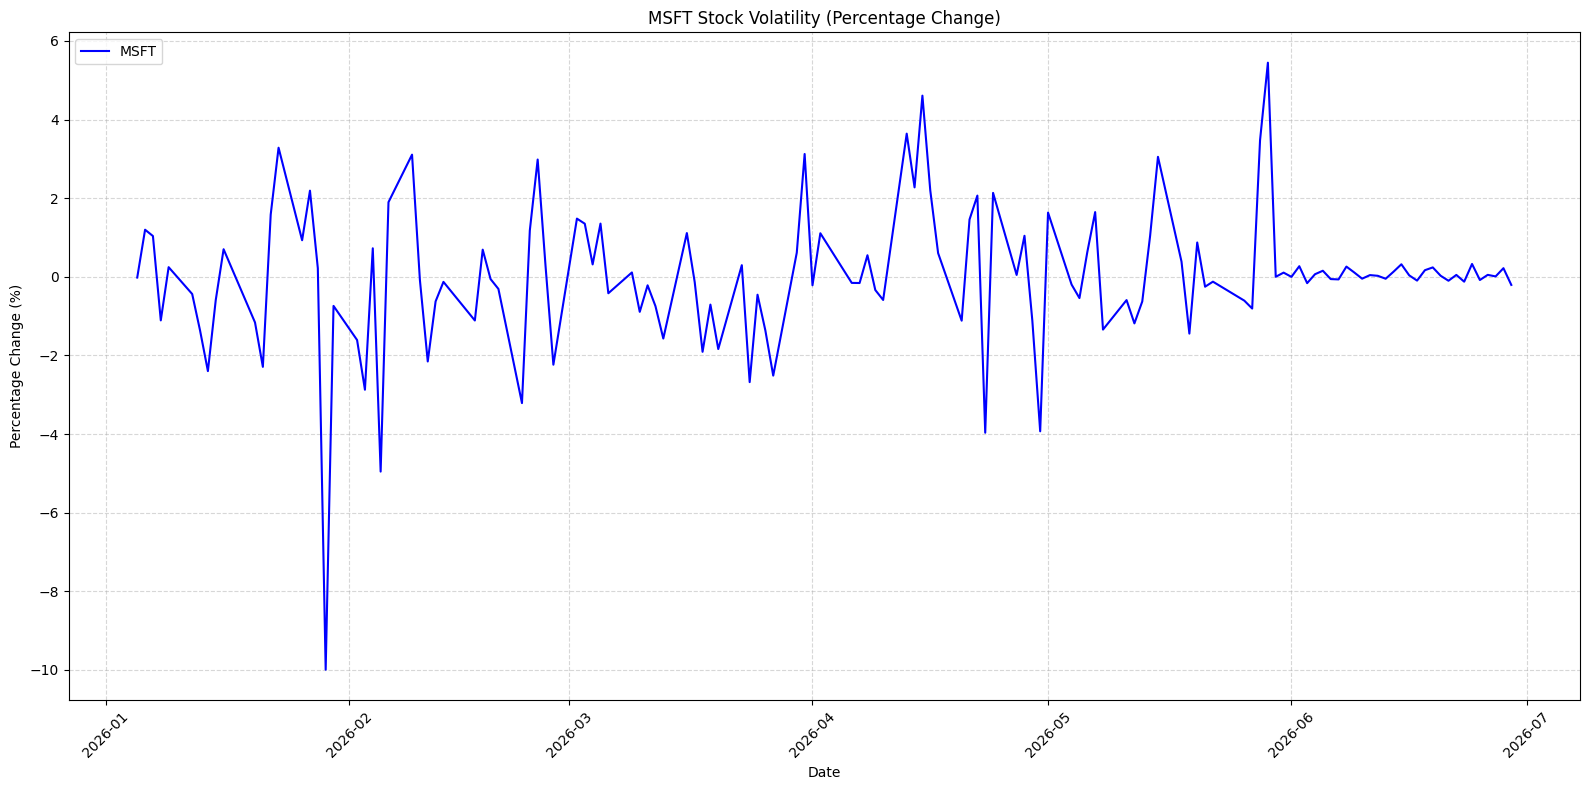

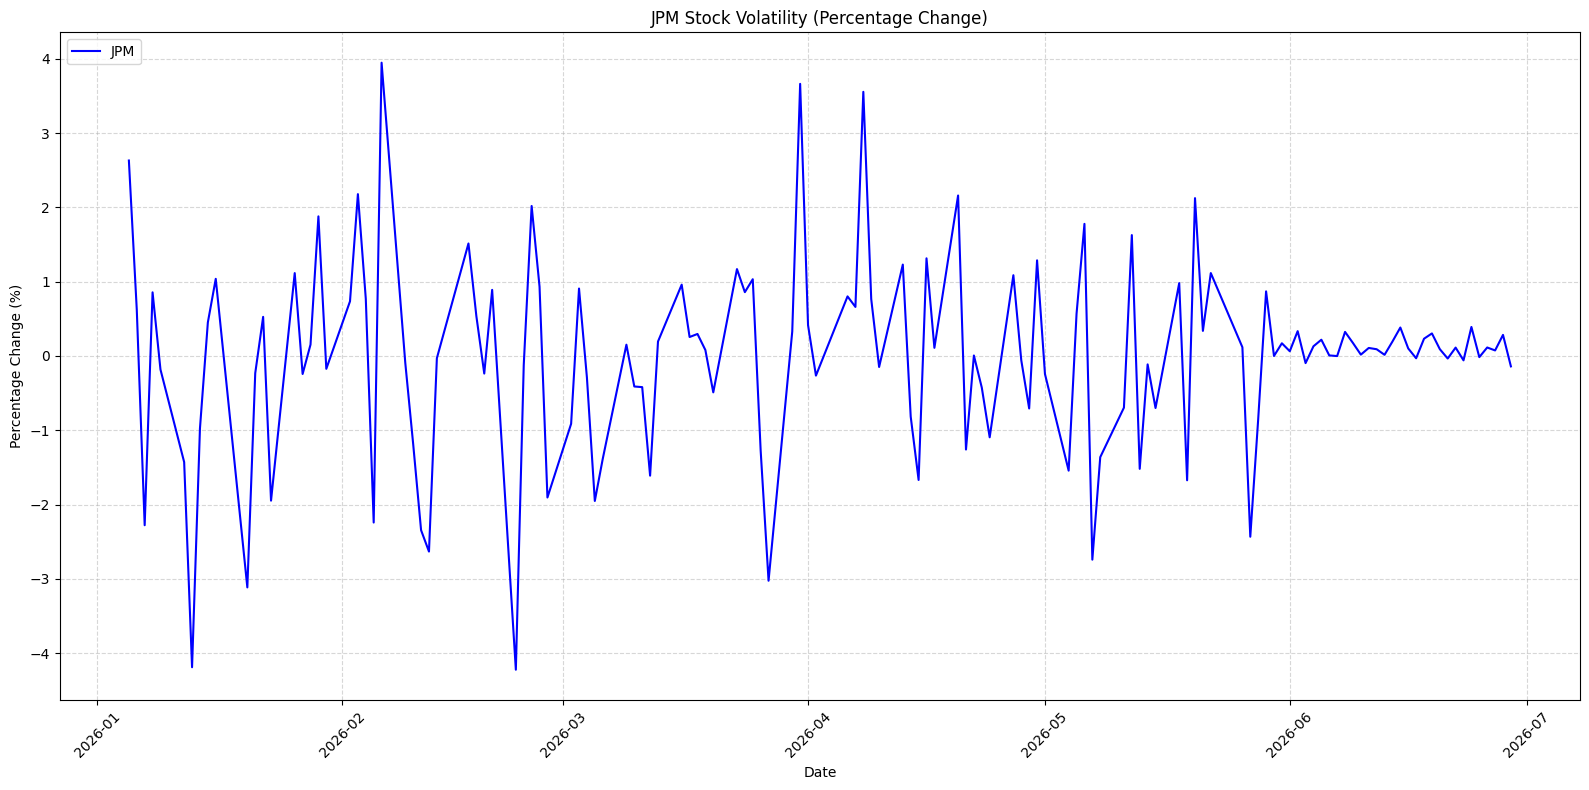

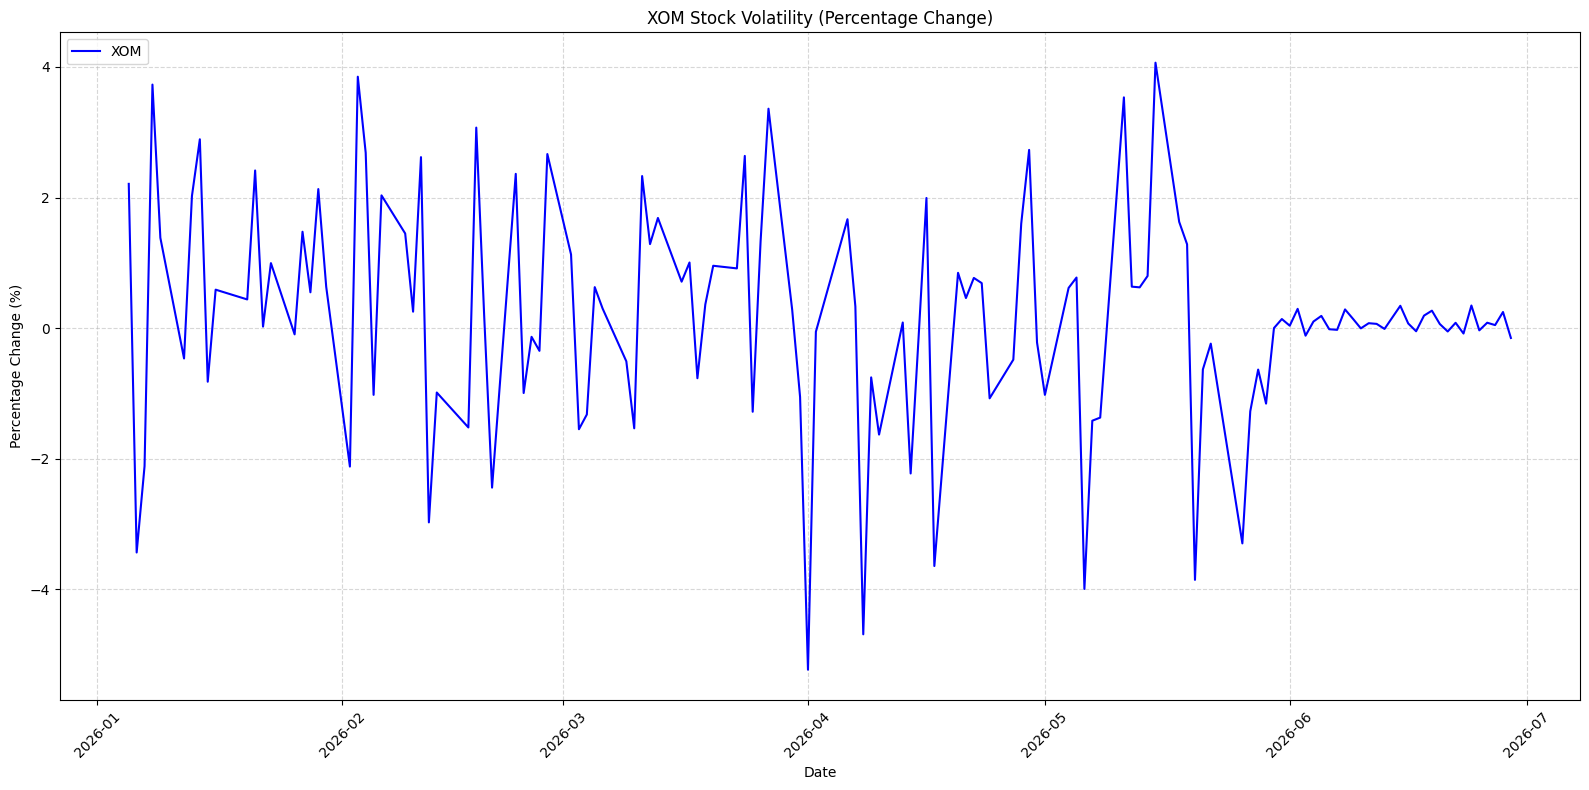

In [ ]:
for column in percentage_change_df.columns:
    plt.figure(figsize=(16, 8))
    plt.plot(percentage_change_df.index, percentage_change_df[column] * 100, label=column, color='blue')
    plt.title(f"{column} Stock Volatility (Percentage Change)")
    plt.xlabel("Date")
    plt.ylabel("Percentage Change (%)")
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
correlation_matrix_ii = june_forecast_df.corr()
print("Correlation Matrix:")
display(correlation_matrix_ii)

variance_covariance_matrix = june_forecast_df.cov()
print("\nVariance-Covariance Matrix:")
display(variance_covariance_matrix)

Correlation Matrix:


,AAPL,MSFT,JPM,XOM
AAPL,1.000000,0.995643,0.999686,0.999956
MSFT,0.995643,1.000000,0.993114,0.995953
JPM,0.999686,0.993114,1.000000,0.999619
XOM,0.999956,0.995953,0.999619,1.000000



Variance-Covariance Matrix:


,AAPL,MSFT,JPM,XOM
AAPL,9.820597,7.335616,10.201525,3.752279
MSFT,7.335616,5.527492,7.603189,2.803807
JPM,10.201525,7.603189,10.603892,3.897737
XOM,3.752279,2.803807,3.897737,1.433806


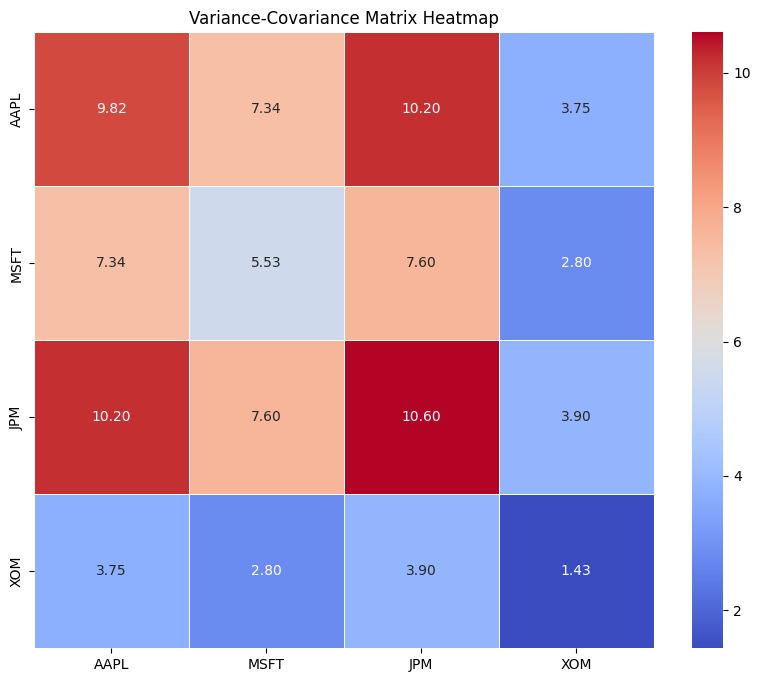

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(variance_covariance_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Variance-Covariance Matrix Heatmap')
plt.show()

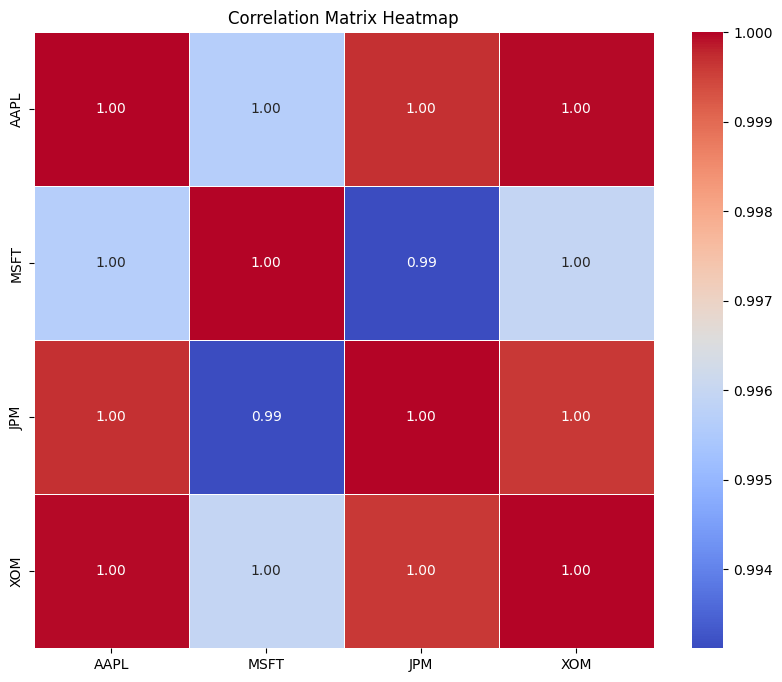

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_ii, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
june_forecast_df.tail()

,AAPL,MSFT,JPM,XOM
Date,,,,
2026-06-25,321.456446,457.171262,309.122824,148.858069
2026-06-26,321.821151,457.395857,309.476097,148.980214
2026-06-27,322.024806,457.437717,309.706947,149.048425
2026-06-28,322.960013,458.438924,310.585574,149.415594
2026-06-29,322.311365,457.490716,310.150842,149.189058


In [ ]:
from google.colab import files

excel_filename = 'june_forecast.xlsx'
june_forecast_df.to_excel(excel_filename, index=True)

files.download(excel_filename)
print(f'Successfully exported {excel_filename}.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully exported june_forecast.xlsx.


Closing prices on 2026-05-31:
AAPL    312.586273
MSFT    450.716789
JPM     299.822049
XOM     145.461270
Name: 2026-05-31 00:00:00, dtype: float64

Generating histograms for actual closing price forecasts for June:


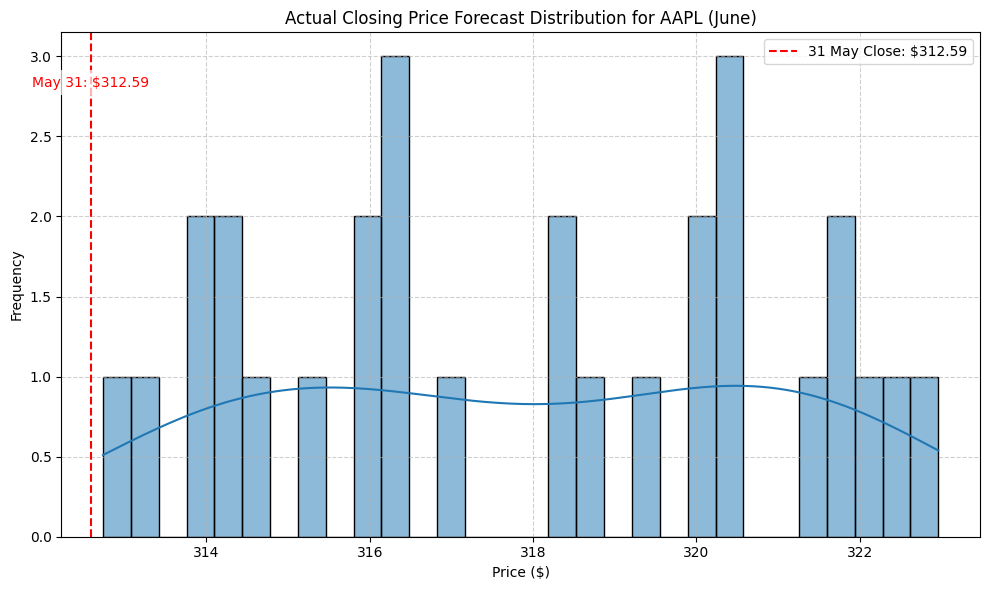

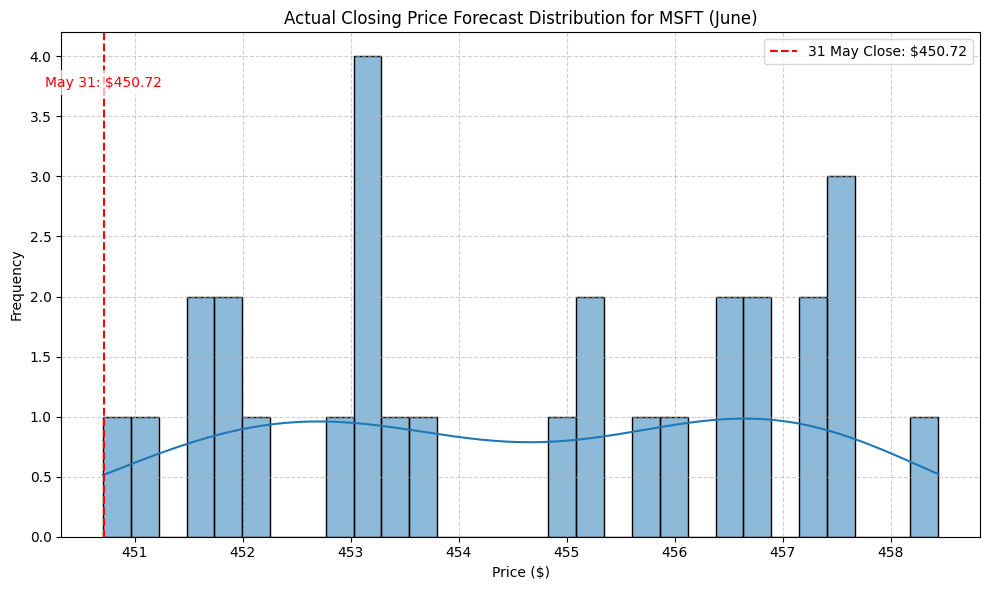

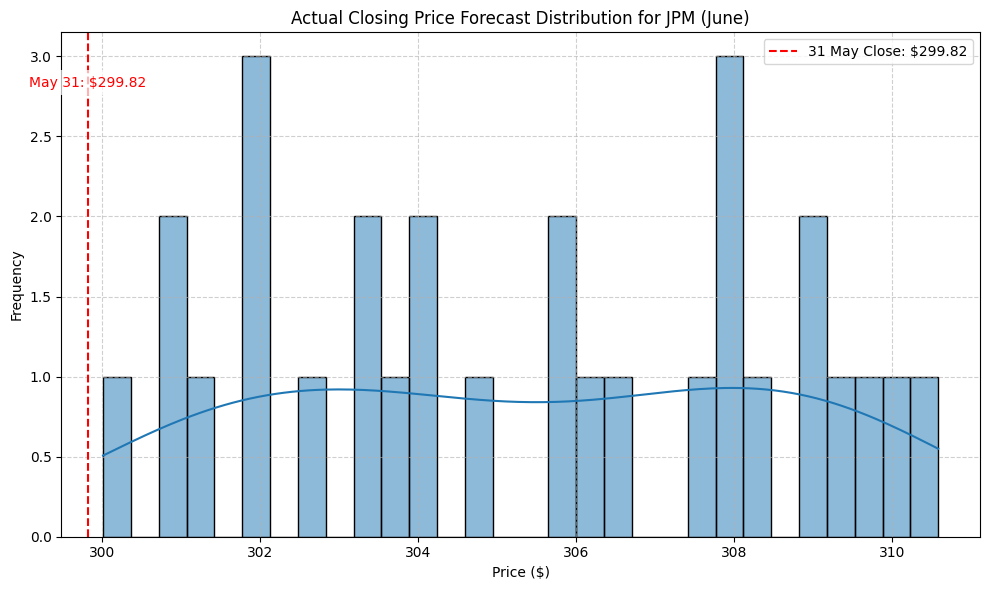

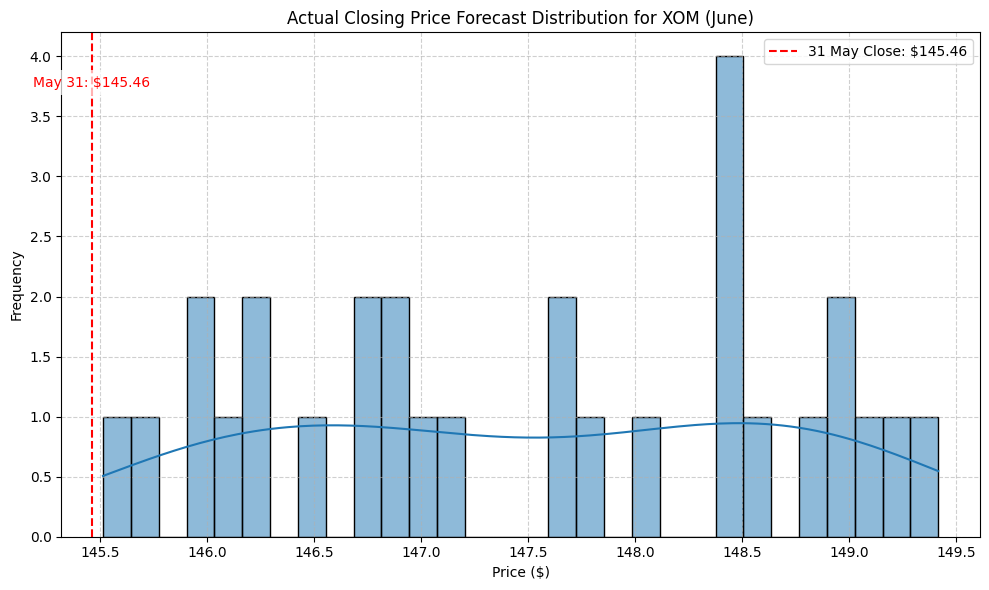

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the existing combined_all_stocks_df DataFrame, which is available in the kernel state.
# We make a copy to prevent unintended modifications to the original DataFrame.
full_forecast_df = combined_all_stocks_df.copy()

# Filter for June data for the histograms, as the previous cell was plotting june_forecast_df.
df_for_histograms = full_forecast_df[full_forecast_df.index.month == 6]

# Define the date for the closing price to be displayed on the plots
may_31_date_str = '2026-05-31'
may_31_date = pd.to_datetime(may_31_date_str)

may_31_prices = None
if may_31_date in full_forecast_df.index:
    may_31_prices = full_forecast_df.loc[may_31_date]
    print(f"Closing prices on {may_31_date.strftime('%Y-%m-%d')}:")
    print(may_31_prices)
else:
    print(f"Warning: Price for {may_31_date.strftime('%Y-%m-%d')} not found in 'combined_all_stocks_df'. Cannot display on plots.")

# Create histograms for the actual closing price forecasts for June
print('\nGenerating histograms for actual closing price forecasts for June:')
for column in df_for_histograms.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_for_histograms[column], bins=30, kde=True)
    plt.title(f'Actual Closing Price Forecast Distribution for {column} (June)')
    plt.xlabel('Price ($)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add the closing price on May 31st to the plot if available
    if may_31_prices is not None and column in may_31_prices:
        may_31_price = may_31_prices[column]
        plt.axvline(may_31_price, color='red', linestyle='--', label=f'31 May Close: ${may_31_price:.2f}')

        # Determine y-coordinate for text. Place it near the top of the plot.
        _, ymax = plt.ylim()
        plt.text(may_31_price, ymax * 0.9, f'May 31: ${may_31_price:.2f}',
                 color='red', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        plt.legend() # Display legend for the vertical line

    plt.tight_layout()
    plt.show()